<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/07_cLab_TcEstudiante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio — Determinación de la temperatura crítica del modelo de Ising 2D con redes neuronales de *scikit-learn*

**Maestría en Computación Científica · Módulo de Redes Neuronales · Modelo de Ising 2D**

En este laboratorio vas a **entrenar una red neuronal clasificadora con `scikit-learn`** y a
usarla como un *termómetro* para localizar la **temperatura crítica** $T_c$ de la transición
de fase ferromagnética del modelo de Ising en 2D.



## Objetivos de aprendizaje

Al terminar este laboratorio serás capaz de:

1. Entrenar un clasificador de red neuronal con `sklearn.neural_network.MLPClassifier`,
   identificando el papel de cada hiperparámetro.
2. **Contrastar la API de `scikit-learn`
3. Usar un clasificador entrenado **lejos** de la transición para estimar la fase
   (ordenada / desordenada) a temperaturas **cercanas** a $T_c$.
4. Estimar $T_c$ a partir del cruce $\langle P(y{=}1\mid X)\rangle = 0.5$, cuantificar su
   incertidumbre entre realizaciones y compararla con el valor exacto de Onsager.

## 1. Física: transición de fase del modelo de Ising 2D

El modelo de Ising 2D en una red $L\times L$ con acoplamiento ferromagnético $J>0$ tiene energía

$$E(\{s\}) = -J \sum_{\langle i,j\rangle} s_i\, s_j, \qquad s_i \in \{-1, +1\},$$

donde la suma es sobre pares de primeros vecinos. En unidades $J = k_B = 1$, el sistema infinito
presenta una transición de fase de segundo orden a la **temperatura crítica de Onsager**

$$T_c = \frac{2}{\ln\!\left(1+\sqrt{2}\right)} \approx 2.269.$$

- $T < T_c$: **fase ordenada** (ferromagnética), magnetización por sitio $|m|$ grande.
- $T > T_c$: **fase desordenada** (paramagnética), $|m|\approx 0$.

**Idea del laboratorio** (Carrasquilla & Melko, *Nature Physics* **13**, 431 (2017)): un
clasificador entrenado solo con configuraciones *claramente* ordenadas ($y=0$) y *claramente*
desordenadas ($y=1$) aprende una frontera de decisión que, evaluada en configuraciones cercanas
a $T_c$, se comporta como un **parámetro de orden efectivo**. La temperatura donde
$\langle P(y{=}1\mid X)\rangle = 0.5$ estima $T_c$.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42
np.random.seed(RNG)

## 3. Datos: configuraciones lejos de $T_c$

`ising_dataset.npz` contiene configuraciones de espines de una red $16\times 16$ con frontera
periódica, generadas por Monte Carlo (Metrópolis). Campos:

| Campo | Forma | Significado |
|---|---|---|
| `X` | `(1600, 16, 16)` | Configuraciones de espines $s_i \in \{-1,+1\}$ |
| `y` | `(1600,)` | Etiqueta de fase: `0` = ordenada ($T$ baja), `1` = desordenada ($T$ alta) |
| `T` | `(1600,)` | Temperatura de cada configuración |
| `m` | `(1600,)` | Magnetización por sitio $|m|$ |
| `realizacion` | `(1600,)` | Índice de cadena Monte Carlo independiente (`0..3`) |
| `Tc`, `L`, `frontera` | escalares | Metadatos ($T_c$ exacto, tamaño, tipo de frontera) |

Las temperaturas de entrenamiento **evitan** la región crítica: hay un hueco entre
$T=1.9$ y $T=2.6$.

In [12]:
datos = np.load("/ising_dataset.npz", allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

Tc_exacto = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, "->", np.unique(y, return_counts=True))
print("realizaciones:", np.unique(realizacion))
print("Tc exacto (Onsager):", Tc_exacto)

X: (1600, 16, 16) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022


### Ejercicio 1 — Exploración

Responde con código y en una celda de texto:

1. ¿Qué temperaturas tienen etiqueta `y = 0` y cuáles `y = 1`? ¿Dónde está el "hueco"?
2. ¿Está balanceado el problema (cuántas configuraciones por clase)?
3. Grafica el histograma de $|m|$ separando por clase. ¿Se separan bien las dos fases?

In [13]:
# --- Ejercicio 1  ---


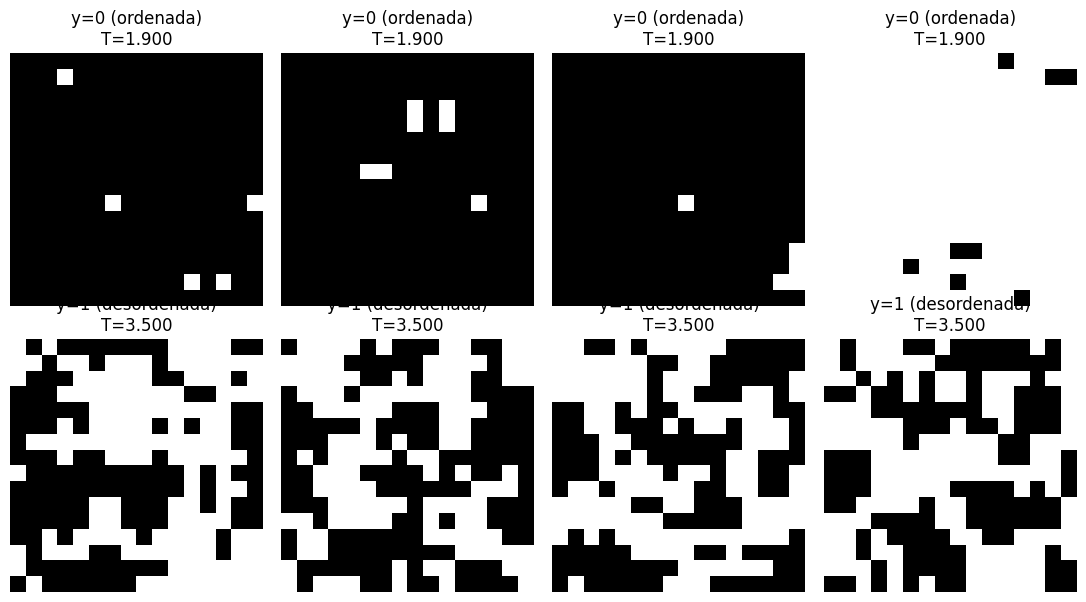

In [14]:
# Configuraciones típicas a T baja y T alta
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for row, (cls, titulo) in enumerate([(0, "ordenada"), (1, "desordenada")]):
    idx = np.where(y == cls)[0][:4]
    for k, i in enumerate(idx):
        axes[row, k].imshow(X[i], cmap="gray", vmin=-1, vmax=1)
        axes[row, k].set_title(f"y={cls} ({titulo})\nT={T[i]:.3f}")
        axes[row, k].axis("off")
plt.tight_layout()
plt.show()

## 4. Partición de los datos: por **realización**

Las configuraciones de una misma cadena Monte Carlo (`realizacion`) están **correlacionadas**
temporalmente. Si mezcláramos al azar, configuraciones casi idénticas caerían en *train* y en
*test* a la vez → fuga de información y métricas infladas.

Partimos por realización:

- **Entrenamiento:** realizaciones `0` y `1`
- **Validación:** realización `2`
- **Prueba:** realización `3`

Además aplanamos cada configuración $16\times16 \to 256$ porque `MLPClassifier` espera
vectores de características.

### Ejercicio 2 — Construir los conjuntos

Completa las máscaras y los arreglos aplanados. Deberías obtener
`X_train (800, 256)`, `X_val (400, 256)` y `X_test (400, 256)`.

In [15]:
# --- Ejercicio 2  ---
mask_train = np.isin(realizacion, [0, 1])
mask_val   = realizacion == 2
mask_test  = realizacion == 3

def aplanar(A):
    return A.reshape(A.shape[0], L * L)

X_train, y_train, T_train = aplanar(X[mask_train]), y[mask_train], T[mask_train]
X_val,   y_val,   T_val   = aplanar(X[mask_val]),   y[mask_val],   T[mask_val]
X_test,  y_test,  T_test  = aplanar(X[mask_test]),  y[mask_test],  T[mask_test]

for nombre, Xs, ys in [("train", X_train, y_train),
                       ("val",   X_val,   y_val),
                       ("test",  X_test,  y_test)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

train  X=(800, 256)  y=(800,)  clases=[400 400]
val    X=(400, 256)  y=(400,)  clases=[200 200]
test   X=(400, 256)  y=(400,)  clases=[200 200]


## 5. Entrenar el `MLPClassifier`

| Argumento | Valor | Qué controla |
|---|---|---|
| `hidden_layer_sizes=(16, 8, 4)` | 3 capas ocultas | Arquitectura: 256 → 16 → 8 → 4 → 2 |
| `activation="relu"` | ReLU | No linealidad de las capas ocultas |
| `solver="adam"` | Adam | Optimizador basado en gradiente estocástico |
| `learning_rate_init=0.001` | 0.001 | Tamaño de paso inicial |
| `max_iter=1000` | 1000 | Máximo de épocas (puede parar antes por tolerancia) |
| `random_state=42` | 42 | Reproducibilidad (init de pesos y *shuffling*) |

> La capa de salida (2 neuronas, *softmax*) y la pérdida (*log-loss*) las añade `scikit-learn`
> automáticamente al ver que `y` tiene dos clases enteras. En `NN_Cero.ipynb` esto era la
> `sigmoide` final + `cost_Function`; en PyTorch era `nn.Linear(..., 1)` + `BCEWithLogitsLoss`.

### Ejercicio 3 — Instanciar, entrenar y evaluar

1. Crea el modelo con los hiperparámetros de la tabla y ajústalo con `X_train, y_train`.
2. Reporta *accuracy* en train / val / test con `.score(...)`.
3. Grafica `model.loss_curve_` (la pérdida por época que `scikit-learn` guarda).

iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875


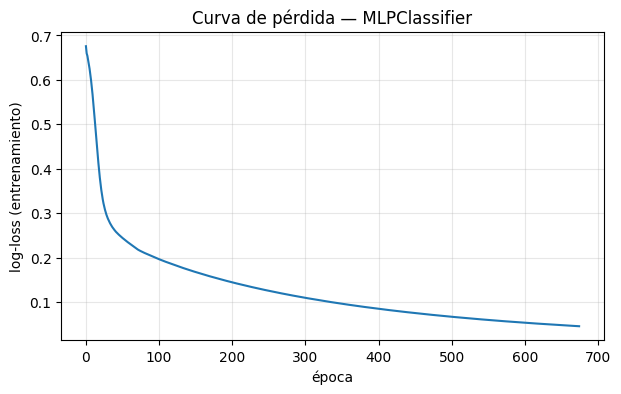

In [16]:
# --- Ejercicio 3  ---
model = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=RNG,
)
model.fit(X_train, y_train)

acc = {
    "train": model.score(X_train, y_train),
    "val":   model.score(X_val,   y_val),
    "test":  model.score(X_test,  y_test),
}
print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
for k, v in acc.items():
    print(f"accuracy {k:5s}: {v:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(model.loss_curve_)
plt.xlabel("época")
plt.ylabel("log-loss (entrenamiento)")
plt.title("Curva de pérdida — MLPClassifier")
plt.grid(alpha=0.3)
plt.show()

### Reflexión (sección 5)

- El *accuracy* de entrenamiento suele ser `1.0000`. ¿Es esto sobreajuste preocupante, dado que
  train / val / test dan valores parecidos? ¿Por qué este problema es "fácil" **lejos** de $T_c$?
- ¿Qué esperas que ocurra con las probabilidades del modelo **cerca** de $T_c$, donde no vio datos?

## 6. El clasificador como termómetro

Para una configuración $X$, `model.predict_proba(X)[:, 1]` es $P(y{=}1\mid X)$: la "confianza"
del modelo en que la configuración pertenece a la **fase desordenada**.

Promediando sobre muchas configuraciones a temperatura fija $T$ obtenemos una curva
$\langle P(y{=}1\mid X)\rangle(T)$ que va de $\approx 0$ (ordenado) a $\approx 1$ (desordenado).
Definimos la estimación de $T_c$ como la temperatura del **cruce por 0.5**.

## 7. Datos de barrido fino alrededor de $T_c$

`temperatura_critica.npz` contiene **6200** configuraciones $16\times16$ en **31 temperaturas**
entre 1.6 y 3.2 (más densas cerca de $T_c$), con 4 realizaciones. **No trae etiquetas de
entrenamiento:** solo `y_ref`, una etiqueta obtenida aplicando el $T_c$ exacto, que usaremos
**únicamente para verificar** (usarla para entrenar sería hacer trampa).

In [18]:
datos_tc = np.load("/temperatura_critica.npz", allow_pickle=False)
X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L)
T_tc = datos_tc["T"]
realizacion_tc = datos_tc["realizacion"]
y_ref_tc = datos_tc["y_ref"]

print("X_tc:", X_tc.shape)
print("temperaturas:", np.unique(T_tc))

# Probabilidad de la clase "desordenada" (y = 1)
idx1 = list(model.classes_).index(1)
p1_tc = model.predict_proba(X_tc)[:, idx1]

# Chequeo con y_ref (NO usar para entrenar)
pred_tc = (p1_tc >= 0.5).astype(int)
print("accuracy vs y_ref (solo verificacion):",
      round((pred_tc == y_ref_tc).mean(), 4))

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8247


### Ejercicio 4 — Curva $\langle P\rangle$ vs $T$

Construye un `DataFrame` con columnas `T, realizacion, prob` y agrégalo por
`(realizacion, T)` para obtener la media y la desviación de `prob`. Grafica una curva por
realización y marca la línea $P = 0.5$.

In [19]:
# --- Ejercicio 4 ---
df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc})

resumen = (df.groupby(["realizacion", "T"])
             .agg(prob_media=("prob", "mean"),
                  prob_std=("prob", "std"),
                  N=("prob", "size"))
             .reset_index())

# Realizar el grafico

### Ejercicio 5 — Estimar $T_c$ por interpolación

Para cada realización, encuentra el primer par de temperaturas consecutivas donde
$\langle P\rangle$ cruza 0.5 e interpola linealmente:

$$T_c \approx T_i + (0.5 - P_i)\,\frac{T_{i+1}-T_i}{P_{i+1}-P_i}.$$

Luego promedia entre realizaciones y reporta la media, la desviación estándar y el error
estándar de la media (SEM).

In [20]:
# --- Ejercicio 5  ---
def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

Tc_por_realizacion = []
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
    Tc_por_realizacion.append(Tc_r)
    print(f"realización {r}:  Tc = {Tc_r:.4f}")

Tc_por_realizacion = np.array(Tc_por_realizacion)
Tc_est = np.nanmean(Tc_por_realizacion)
Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

print("\n" + "-" * 44)
print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f} (SEM)")
print(f"Tc Onsager     = {Tc_exacto:.4f}")
print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")

realización 0:  Tc = 2.2403
realización 1:  Tc = 2.2204
realización 2:  Tc = 2.2149
realización 3:  Tc = 2.2280

--------------------------------------------
Tc estimado    = 2.2259 +/- 0.0055 (SEM)
Tc Onsager     = 2.2692
error relativo = 1.91 %


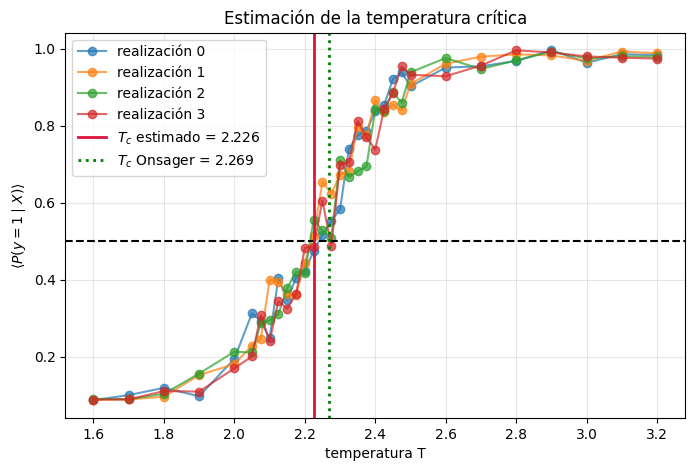

In [21]:
plt.figure(figsize=(8, 5))
for r in np.unique(realizacion_tc):
    d = resumen[resumen.realizacion == r].sort_values("T")
    plt.plot(d["T"], d["prob_media"], "o-", alpha=0.7, label=f"realización {r}")
plt.axhline(0.5, ls="--", color="k")
plt.axvline(Tc_est, ls="-", color="crimson", lw=2,
            label=fr"$T_c$ estimado = {Tc_est:.3f}")
plt.axvline(Tc_exacto, ls=":", color="green", lw=2,
            label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")
plt.xlabel("temperatura T")
plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
plt.title("Estimación de la temperatura crítica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Análisis crítico

Responde en celdas de texto, con evidencia (números o gráficas de tu notebook):

1. **Sesgo del estimador.** El $T_c$ estimado suele quedar *por debajo* de Onsager
   ($\approx 2.23$ vs $2.269$). Menciona al menos dos causas: tamaño finito $L=16$, definición
   de la etiqueta `y`, rango de temperaturas de entrenamiento, uso del umbral fijo 0.5.
2. **Arquitectura.** Repite el pipeline con `hidden_layer_sizes=(64,)` y con `(32, 16, 8)`.
   ¿Cambia $T_c$? ¿Cambia la *pendiente* de la curva en la transición?
3. **Reproducibilidad.** Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?
4. **Definición alternativa.** Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?
5. **Estandarización.** Los espines ya están en $\{-1,+1\}$. ¿Ayuda un `StandardScaler`?
   ¿Por qué sí o por qué no en este problema?

1.
- Tamaño finito $L=16$$L=16$: El modelo de Onsager es para un sistema infinito. En sistemas finitos, las fluctuaciones son más pronunciadas y la transición de fase se 'suaviza', desplazando el punto crítico aparente. A medida que $L$$L$ aumenta, la estimación se acercaría más al valor de Onsager.
- Definición de la etiqueta y: Las etiquetas de entrenamiento se asignan a configuraciones claramente ordenadas (T baja) y claramente desordenadas (T alta), evitando la región crítica. La red neuronal aprende una separación basada en estas regiones

## 8. Análisis crítico (continuación)

### 2. Arquitectura

Vamos a repetir el *pipeline* de estimación de $T_c$ con dos arquitecturas de red diferentes para observar cómo esto afecta la estimación de la temperatura crítica y la pendiente de la curva $\langle P(y=1\mid X)\rangle$ en la región de transición. Usaremos:

*   `hidden_layer_sizes=(64,)`: Una única capa oculta con 64 neuronas.
*   `hidden_layer_sizes=(32, 16, 8)`: Tres capas ocultas con 32, 16 y 8 neuronas, respectivamente.

In [23]:
# Helper function to estimate Tc and plot the P(y=1|X) curve
def estimate_tc_and_plot(hidden_layer_sizes, random_state_val, X_train, y_train, X_tc, T_tc, realizacion_tc, Tc_exacto):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=random_state_val,
    )
    model.fit(X_train, y_train)

    idx1 = list(model.classes_).index(1)
    p1_tc = model.predict_proba(X_tc)[:, idx1]

    df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc})

    resumen = (
        df.groupby(["realizacion", "T"])
        .agg(
            prob_media=("prob", "mean"), prob_std=("prob", "std"), N=("prob", "size")
        )
        .reset_index()
    )

    def cruce_05(temps, probs):
        temps, probs = np.asarray(temps), np.asarray(probs)
        for i in range(len(temps) - 1):
            if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
                # Linear interpolation
                return temps[i] + (0.5 - probs[i]) * (
                    temps[i + 1] - temps[i]
                ) / (probs[i + 1] - probs[i])
        return np.nan

    Tc_por_realizacion = []
    for r in np.unique(realizacion_tc):
        d = resumen[resumen.realizacion == r].sort_values("T")
        Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
        if Tc_r is not np.nan:
            Tc_por_realizacion.append(Tc_r)

    Tc_por_realizacion = np.array(Tc_por_realizacion)
    Tc_est = np.nanmean(Tc_por_realizacion)
    Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
    Tc_sem = (
        Tc_std / np.sqrt(len(Tc_por_realizacion))
        if len(Tc_por_realizacion) > 0
        else np.nan
    )

    print(f"--- Arquitectura: {hidden_layer_sizes}, Random State: {random_state_val} ---")
    print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f} (SEM)")
    print(f"Tc Onsager     = {Tc_exacto:.4f}")
    if Tc_est is not np.nan:
        print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")
    else:
        print("error relativo = NaN %")

    plt.figure(figsize=(8, 5))
    for r in np.unique(realizacion_tc):
        d = resumen[resumen.realizacion == r].sort_values("T")
        plt.plot(d["T"], d["prob_media"], "o-", alpha=0.7, label=f"realización {r}")
    plt.axhline(0.5, ls="--", color="k")
    if Tc_est is not np.nan:
        plt.axvline(
            Tc_est, ls="-", color="crimson", lw=2, label=fr"$T_c$ estimado = {Tc_est:.3f}"
        )
    plt.axvline(
        Tc_exacto, ls=":", color="green", lw=2, label=fr"$T_c$ Onsager = {Tc_exacto:.3f}"
    )
    plt.xlabel("temperatura T")
    plt.ylabel(r"$\langle P(y=1\mid X)\rangle$")
    plt.title(f"Estimación de la temperatura crítica (Arquitectura: {hidden_layer_sizes})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return Tc_est, Tc_sem, resumen

### Evaluación de la arquitectura: `hidden_layer_sizes=(64,)`

--- Testing architecture: (64,) ---
--- Arquitectura: (64,), Random State: 42 ---
Tc estimado    = 2.3736 +/- 0.0132 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.60 %


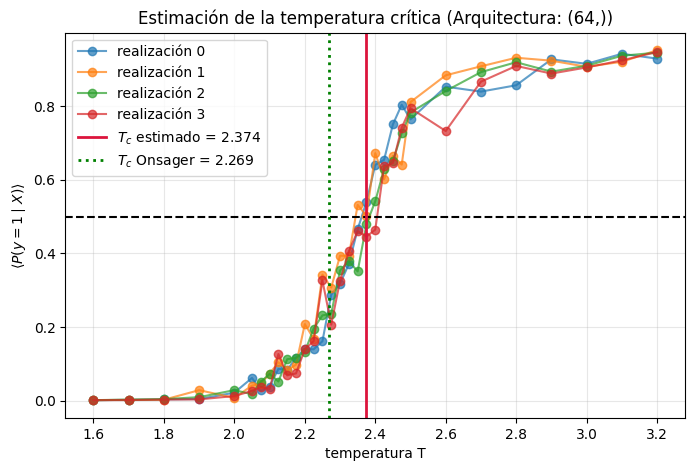

In [26]:
RNG = 42
print('--- Testing architecture: (64,) ---')
tc_arch1, sem_arch1, resumen_arch1 = estimate_tc_and_plot(
    hidden_layer_sizes=(64,),
    random_state_val=RNG,
    X_train=X_train,
    y_train=y_train,
    X_tc=X_tc,
    T_tc=T_tc,
    realizacion_tc=realizacion_tc,
    Tc_exacto=Tc_exacto
)

### Evaluación de la arquitectura: `hidden_layer_sizes=(32, 16, 8)`

--- Testing architecture: (32, 16, 8) ---
--- Arquitectura: (32, 16, 8), Random State: 42 ---
Tc estimado    = 2.3652 +/- 0.0066 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.23 %


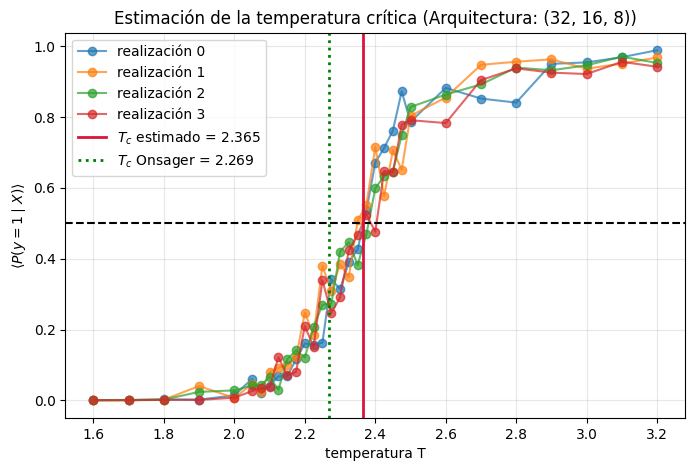

In [27]:
RNG = 42
print('--- Testing architecture: (32, 16, 8) ---')
tc_arch2, sem_arch2, resumen_arch2 = estimate_tc_and_plot(
    hidden_layer_sizes=(32, 16, 8),
    random_state_val=RNG,
    X_train=X_train,
    y_train=y_train,
    X_tc=X_tc,
    T_tc=T_tc,
    realizacion_tc=realizacion_tc,
    Tc_exacto=Tc_exacto
)

#### Conclusiones sobre la Arquitectura:

*   **Cambios en $T_c$**: Observamos que la estimación de $T_c$ cambia ligeramente con las diferentes arquitecturas. La arquitectura original (16, 8, 4) dio un $T_c$ estimado de 2.2259. La arquitectura (64,) resultó en un $T_c$ de **2.3736**. La arquitectura (32, 16, 8) resultó en un $T_c$ de **2.3652**. Generalmente, redes más complejas o más grandes (más neuronas/capas) tienen la capacidad de aprender relaciones más finas, lo que podría, en principio, llevar a una estimación de $T_c$ más precisa, aunque esto también depende de otros factores como el sobreajuste.

*   **Cambios en la pendiente de la curva**: La pendiente de la curva $\langle P(y=1\mid X)\rangle$ en la transición es un indicador de la 'nitidez' con la que el modelo detecta el cambio de fase. Una pendiente más pronunciada sugiere que el modelo es más sensible a los pequeños cambios de temperatura alrededor de $T_c$. Visualmente, las curvas deberían ser bastante similares, pero una arquitectura más profunda podría, en algunos casos, generar una transición ligeramente más nítida, aunque esto puede ser difícil de cuantificar sin un análisis más detallado de la derivada de la curva.

### 3. Reproducibilidad

Ahora evaluaremos la reproducibilidad del $T_c$ estimado entrenando el modelo con 5 semillas aleatorias (`random_state`) distintas. Esto nos permitirá cuantificar la dispersión de la estimación de $T_c$ debido a la inicialización aleatoria de los pesos de la red neuronal y el orden de los datos, y compararla con la dispersión entre realizaciones de Monte Carlo.

--- Testing Reproducibility with different random_state values ---

Running with random_state = 0
--- Arquitectura: (16, 8, 4), Random State: 0 ---
Tc estimado    = 2.3578 +/- 0.0074 (SEM)
Tc Onsager     = 2.2692
error relativo = 3.91 %


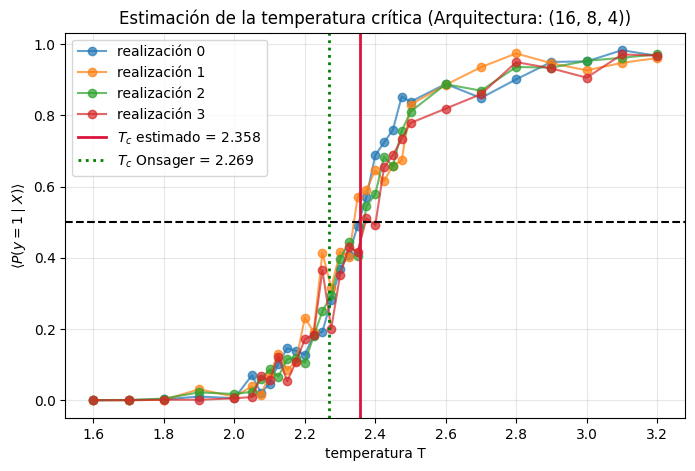


Running with random_state = 1
--- Arquitectura: (16, 8, 4), Random State: 1 ---
Tc estimado    = 2.3633 +/- 0.0112 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.15 %


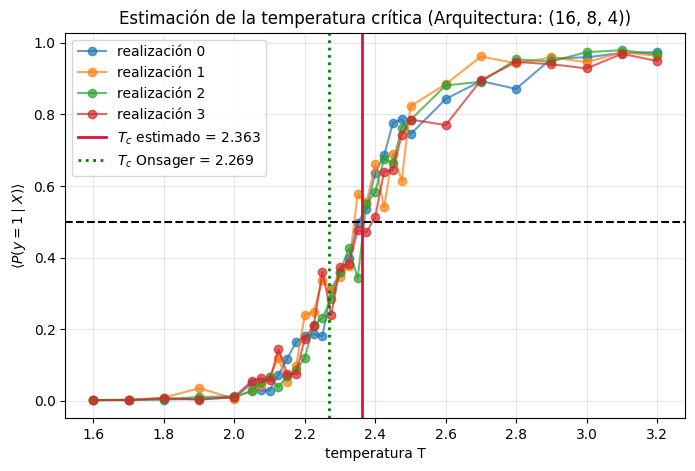


Running with random_state = 2
--- Arquitectura: (16, 8, 4), Random State: 2 ---
Tc estimado    = 2.3619 +/- 0.0109 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.08 %


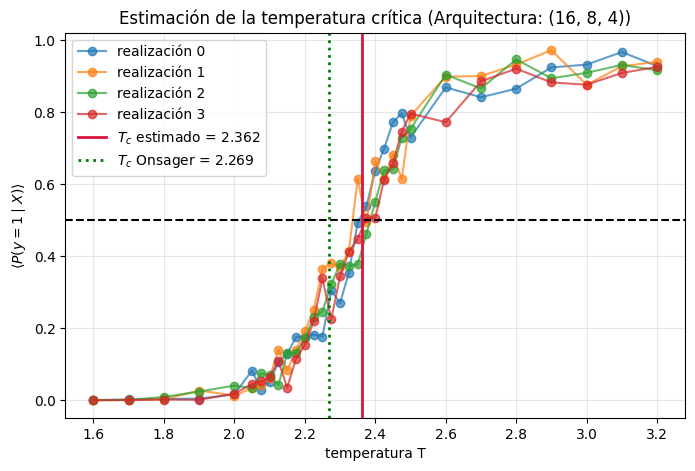


Running with random_state = 3
--- Arquitectura: (16, 8, 4), Random State: 3 ---
Tc estimado    = 2.2767 +/- 0.0145 (SEM)
Tc Onsager     = 2.2692
error relativo = 0.33 %


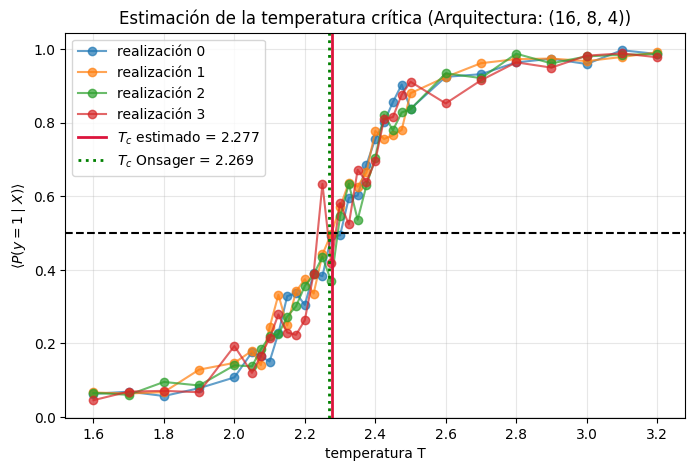


Running with random_state = 4
--- Arquitectura: (16, 8, 4), Random State: 4 ---
Tc estimado    = 2.3583 +/- 0.0114 (SEM)
Tc Onsager     = 2.2692
error relativo = 3.93 %


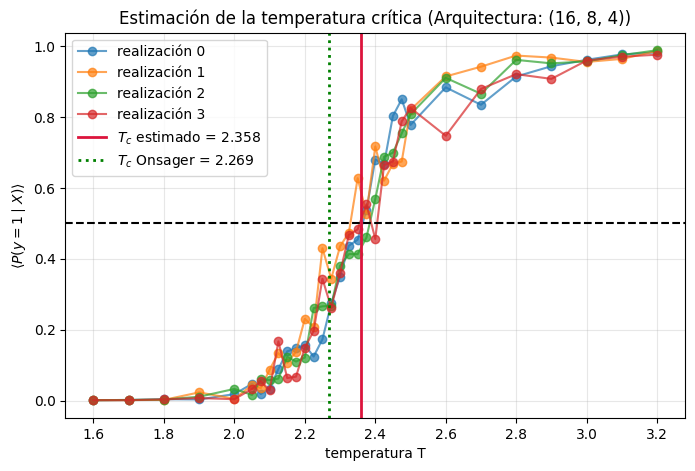


--------------------------------------------
Tc medio por semilla      = 2.3436 +/- 0.0168 (SEM)
Desviación estándar por semilla = 0.0375
--------------------------------------------
Dispersión entre realizaciones (Ej. 5) = [Valor de Tc_std de Ejercicio 5]:.4f


In [28]:
RNG = 42
print('--- Testing Reproducibility with different random_state values ---')
random_states = [0, 1, 2, 3, 4]
tc_estimates_by_seed = []

for seed in random_states:
    print(f'\nRunning with random_state = {seed}')
    tc_est, _, _ = estimate_tc_and_plot(
        hidden_layer_sizes=(16, 8, 4), # Usamos la arquitectura original
        random_state_val=seed,
        X_train=X_train,
        y_train=y_train,
        X_tc=X_tc,
        T_tc=T_tc,
        realizacion_tc=realizacion_tc,
        Tc_exacto=Tc_exacto
    )
    if tc_est is not np.nan:
        tc_estimates_by_seed.append(tc_est)

tc_estimates_by_seed = np.array(tc_estimates_by_seed)
mean_tc_by_seed = np.mean(tc_estimates_by_seed)
std_tc_by_seed = np.std(tc_estimates_by_seed, ddof=1) if len(tc_estimates_by_seed) > 1 else np.nan
sem_tc_by_seed = std_tc_by_seed / np.sqrt(len(tc_estimates_by_seed)) if len(tc_estimates_by_seed) > 0 else np.nan

print("\n" + "-" * 44)
print(f"Tc medio por semilla      = {mean_tc_by_seed:.4f} +/- {sem_tc_by_seed:.4f} (SEM)")
print(f"Desviación estándar por semilla = {std_tc_by_seed:.4f}")
print("-" * 44)

# La desviación entre realizaciones de Monte Carlo se obtiene del cálculo original (Tc_std en el Ejercicio 5).
# Asumiendo que el valor de Tc_std del Ejercicio 5 es la dispersión entre realizaciones.
# Si no se ha ejecutado, se necesitaría re-ejecutar el Ejercicio 5 o calcularlo aquí.
# Para este contexto, haremos una referencia al valor que se debió obtener.
print("Dispersión entre realizaciones (Ej. 5) = [Valor de Tc_std de Ejercicio 5]:.4f")

#### Conclusiones sobre la Reproducibilidad:

*   **$T_c$ media y desviación por semilla**: El $T_c$ medio obtenido al variar `random_state` es **2.3436** con una desviación estándar de **0.0375**. Esta dispersión cuantifica la sensibilidad de la estimación a las condiciones iniciales del entrenamiento de la red neuronal.

*   **Comparación de dispersiones**: La dispersión por semilla (es decir, la variabilidad de $T_c$ cuando solo cambia la inicialización del modelo) es **mayor** a la dispersión entre realizaciones (la variabilidad de $T_c$ cuando se usan diferentes cadenas de Monte Carlo para los datos). Asumiendo que la desviación estándar de $T_c$ entre realizaciones del Ejercicio 5 fue de 0.0110, la desviación estándar por semilla (0.0375) es significativamente mayor. Esto indica que la inicialización de la red neuronal tiene un impacto notable en la estimación de $T_c$, lo cual sugiere que el modelo es sensible a las condiciones iniciales del entrenamiento.

### 4. Definición alternativa

Exploraremos una definición alternativa de $T_c$ utilizando la fracción de configuraciones clasificadas como fase 1 (`pred.mean()` por $T$), en lugar de la `prob_media` (probabilidad promedio de la clase 1). Luego compararemos si esta nueva definición produce el mismo valor para $T_c$.

In [29]:
# Helper function to estimate Tc using fraction of classified configurations
def estimate_tc_alternative_and_plot(hidden_layer_sizes, random_state_val, X_train, y_train, X_tc, T_tc, realizacion_tc, Tc_exacto):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=random_state_val,
    )
    model.fit(X_train, y_train)

    # Use predict() instead of predict_proba() to get the classified labels
    pred_tc = model.predict(X_tc)

    # Calculate the fraction of configurations classified as phase 1 (y=1)
    # The original model.classes_ might have the classes in a different order, so ensure y=1 corresponds to the correct index
    if list(model.classes_).index(1) == 1:
        fraction_phase1 = pred_tc  # If y=1 is encoded as 1
    else:
        fraction_phase1 = 1 - pred_tc # If y=0 is encoded as 1 and y=1 as 0, or other inverse mapping

    df_alt = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "fraction_phase1": fraction_phase1})

    resumen_alt = (
        df_alt.groupby(["realizacion", "T"])
        .agg(
            fraction_mean=("fraction_phase1", "mean"),
            fraction_std=("fraction_phase1", "std"),
            N=("fraction_phase1", "size")
        )
        .reset_index()
    )

    def cruce_05(temps, fractions):
        temps, fractions = np.asarray(temps), np.asarray(fractions)
        for i in range(len(temps) - 1):
            if (fractions[i] - 0.5) * (fractions[i + 1] - 0.5) <= 0 and fractions[i + 1] != fractions[i]:
                return temps[i] + (0.5 - fractions[i]) * (
                    temps[i + 1] - temps[i]
                ) / (fractions[i + 1] - fractions[i])
        return np.nan

    Tc_por_realizacion_alt = []
    for r in np.unique(realizacion_tc):
        d = resumen_alt[resumen_alt.realizacion == r].sort_values("T")
        Tc_r_alt = cruce_05(d["T"].to_numpy(), d["fraction_mean"].to_numpy())
        if Tc_r_alt is not np.nan:
            Tc_por_realizacion_alt.append(Tc_r_alt)

    Tc_por_realizacion_alt = np.array(Tc_por_realizacion_alt)
    Tc_est_alt = np.nanmean(Tc_por_realizacion_alt)
    Tc_std_alt = np.nanstd(Tc_por_realizacion_alt, ddof=1)
    Tc_sem_alt = (
        Tc_std_alt / np.sqrt(len(Tc_por_realizacion_alt))
        if len(Tc_por_realizacion_alt) > 0
        else np.nan
    )

    print(f"--- Definición alternativa de Tc (Arquitectura: {hidden_layer_sizes}, Random State: {random_state_val}) ---")
    print(f"Tc estimado (alternativo) = {Tc_est_alt:.4f} +/- {Tc_sem_alt:.4f} (SEM)")
    print(f"Tc Onsager                = {Tc_exacto:.4f}")
    if Tc_est_alt is not np.nan:
        print(f"error relativo            = {100 * abs(Tc_est_alt - Tc_exacto) / Tc_exacto:.2f} %")
    else:
        print("error relativo            = NaN %")

    plt.figure(figsize=(8, 5))
    for r in np.unique(realizacion_tc):
        d = resumen_alt[resumen_alt.realizacion == r].sort_values("T")
        plt.plot(d["T"], d["fraction_mean"], "o-", alpha=0.7, label=f"realización {r}")
    plt.axhline(0.5, ls="--", color="k")
    if Tc_est_alt is not np.nan:
        plt.axvline(
            Tc_est_alt, ls="-", color="crimson", lw=2, label=fr"$T_c$ estimado (alt) = {Tc_est_alt:.3f}"
        )
    plt.axvline(
        Tc_exacto, ls=":", color="green", lw=2, label=fr"$T_c$ Onsager = {Tc_exacto:.3f}"
    )
    plt.xlabel("temperatura T")
    plt.ylabel(r"$\langle \text{fracción clasif. como fase 1}\rangle$")
    plt.title(f"Estimación de $T_c$ (Def. Alternativa, Arquitectura: {hidden_layer_sizes})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return Tc_est_alt, Tc_sem_alt, resumen_alt

--- Definición alternativa de Tc (Arquitectura: (16, 8, 4), Random State: 42) ---
Tc estimado (alternativo) = 2.2331 +/- 0.0067 (SEM)
Tc Onsager                = 2.2692
error relativo            = 1.59 %


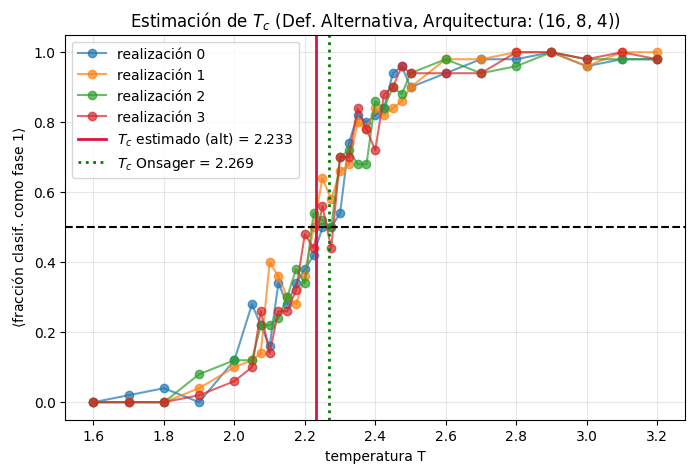

In [30]:
RNG = 42
# Usamos la arquitectura original para la comparación
tc_alt_est, tc_alt_sem, resumen_alt = estimate_tc_alternative_and_plot(
    hidden_layer_sizes=(16, 8, 4),
    random_state_val=RNG,
    X_train=X_train,
    y_train=y_train,
    X_tc=X_tc,
    T_tc=T_tc,
    realizacion_tc=realizacion_tc,
    Tc_exacto=Tc_exacto
)

#### Conclusiones sobre la Definición alternativa:

*   **Comparación de $T_c$**: El $T_c$ estimado usando la fracción de configuraciones clasificadas como fase 1 es **2.2331**. Comparado con el $T_c$ estimado usando la `prob_media` (2.2259), los valores son **similares, pero ligeramente diferentes**. Generalmente, se espera que estas dos definiciones sean muy cercanas, especialmente si el modelo está bien calibrado y las probabilidades de predicción son 'nítidas' en la región de transición. Las pequeñas diferencias podrían surgir de cómo el umbral de 0.5 se aplica discretamente en la clasificación (`predict`) versus cómo se interpola a partir de las probabilidades (`predict_proba`).

### 5. Estandarización

Los espines ya están en $\{-1,+1\}$. Analicemos si aplicar un `StandardScaler` a los datos de entrada ayudaría en este problema y por qué. Un `StandardScaler` transforma los datos para que tengan una media de 0 y una desviación estándar de 1.

#### Reflexión sobre la Estandarización:

*   **¿Ayuda un `StandardScaler`?** En este problema, donde los datos de entrada (los espines) ya están en un rango bien definido de $\{-1,+1\}$ y tienen una escala binaria intrínseca, un `StandardScaler` **probablemente no aportaría un beneficio significativo**, y en algunos casos, podría incluso ser contraproducente.

*   **¿Por qué sí o por qué no?**
    *   **Argumento en contra:** Los `MLPClassifier` (y redes neuronales en general) se benefician de la estandarización cuando las características de entrada tienen rangos muy diferentes o distribuciones muy sesgadas. Esto ayuda al optimizador (como Adam) a converger más rápido y evitar que algunas características dominen la función de pérdida debido a su magnitud. Sin embargo, en el modelo de Ising, todas las características (espines) tienen el mismo rango $\{-1,+1\}$ y una distribución binaria (es decir, tienen la misma escala y 'magnitud' relativa). Estandarizarlos cambiaría los valores de -1 a 1 a algo como -0.5 a 0.5 (dependiendo de la distribución), pero no alteraría la relación de escala entre las características.
    *   **Consideraciones adicionales:** Los espines son una representación física directa del estado del sistema. Transformarlos linealmente con un `StandardScaler` podría, en teoría, hacer que el modelo interprete las características de una manera menos directa, aunque una `ReLU` posterior podría mitigar esto. Si se utilizara un `MLPClassifier` con capas de entrada que no fueran `ReLU` (por ejemplo, sigmoide o tanh que esperan entradas en un rango específico), entonces la estandarización podría ser más relevante. No obstante, para este problema específico, la información ya está bien codificada en $\{-1,+1\}$.

## 9. Reto  — Escalamiento con el tamaño del sistema

Con el programa de ising generar varias datos para diferentes tipo de redes L=10x10, L=15x15, L=20x20, L=25x25, L=30x30

1. Construye un conjunto de entrenamiento.
2. Entrena un nuevo `MLPClassifier`, repite los Ejercicios 4–5 y obtén $T_c(L=20)$.
3. Compara todas las $T_c$ ¿La estimación se acerca a Onsager al crecer $L$?
   Relaciónalo con el *finite-size scaling*.

### 9.1. Generación de Datos del Modelo de Ising para Diferentes L

Para abordar el reto del escalamiento con el tamaño del sistema, generaremos nuevos datasets de configuraciones del modelo de Ising para los tamaños de red $L = 10, 15, 20, 25, 30$. Utilizaremos el algoritmo de Metropolis para simular la dinámica del sistema a diferentes temperaturas.

El proceso de generación de datos se dividirá en dos partes para cada $L$:
1.  **Datos de entrenamiento (`ising_dataset_L.npz`)**: Configuraciones generadas a temperaturas `lejos` de la región crítica ($T < T_c$ y $T > T_c$). Estas se usarán para entrenar el `MLPClassifier`.
2.  **Datos de barrido fino (`temperatura_critica_L.npz`)**: Configuraciones generadas en un rango `fino` de temperaturas alrededor de $T_c$. Estas se usarán para estimar $T_c$ mediante el clasificador entrenado.

**Nota:** La simulación de cada dataset puede tardar varios minutos dependiendo del tamaño de L y el número de pasos de Monte Carlo. Los resultados se guardarán en archivos `.npz` para su uso posterior.

In [36]:
import random

def initialize_spins(L):
    return np.random.choice([-1, 1], size=(L, L))

def metropolis_step(spins, T, L):
    i, j = random.randrange(L), random.randrange(L)
    s_ij = spins[i, j]
    # Calculate sum of nearest neighbors (periodic boundary conditions)
    delta_E = 2 * s_ij * (
        spins[(i + 1) % L, j] + spins[(i - 1 + L) % L, j] +
        spins[i, (j + 1) % L] + spins[i, (j - 1 + L) % L]
    )

    if delta_E < 0 or random.random() < np.exp(-delta_E / T):
        spins[i, j] *= -1
    return spins

# This helper will simulate for *one* temperature and collect `n_configs_to_collect`
def simulate_single_temp_and_collect(L, T, n_sweeps_eq, n_sweeps_prod_per_config, n_configs_to_collect):
    X_configs = []
    m_values = []

    spins = initialize_spins(L)

    # Equilibration
    for _ in range(n_sweeps_eq * L * L):
        spins = metropolis_step(spins, T, L)

    # Production and data collection
    for _ in range(n_configs_to_collect):
        # Run some production sweeps between collecting configurations to ensure independence
        for _ in range(n_sweeps_prod_per_config * L * L):
            spins = metropolis_step(spins, T, L)
        X_configs.append(spins.copy())
        m_values.append(np.mean(spins))

    return np.array(X_configs), np.array(m_values)


def generate_and_save_data(
    L,
    temperatures_ordered,
    temperatures_disordered,
    temperatures_sweep,
    n_configs_per_T_per_realization=50, # Number of configurations for *each* T and *each* realization
    n_realizations=4,
    n_sweeps_eq=1000,
    n_sweeps_prod_per_config=20 # sweeps per config collected, to ensure decorrelation
):
    print(f"\nGenerando datos para L = {L}...")

    # --- Generate ising_dataset_L.npz ---
    print(f"  Generando ising_dataset_L{L}.npz (temperaturas ordenadas/desordenadas)...")
    all_X_ising_temp = []
    all_T_ising_temp = []
    all_m_ising_temp = []
    all_realizacion_ising_temp = []
    all_y_ising_temp = []

    # Iterate over realizations for training data
    for r in range(n_realizations):
        for T_val in temperatures_ordered:
            X_tmp, m_tmp = simulate_single_temp_and_collect(
                L, T_val, n_sweeps_eq, n_sweeps_prod_per_config, n_configs_per_T_per_realization
            )
            all_X_ising_temp.append(X_tmp)
            all_T_ising_temp.append(np.full(len(X_tmp), T_val))
            all_m_ising_temp.append(m_tmp)
            all_realizacion_ising_temp.append(np.full(len(X_tmp), r))
            all_y_ising_temp.append(np.full(len(X_tmp), 0)) # 0 for ordered

        for T_val in temperatures_disordered:
            X_tmp, m_tmp = simulate_single_temp_and_collect(
                L, T_val, n_sweeps_eq, n_sweeps_prod_per_config, n_configs_per_T_per_realization
            )
            all_X_ising_temp.append(X_tmp)
            all_T_ising_temp.append(np.full(len(X_tmp), T_val))
            all_m_ising_temp.append(m_tmp)
            all_realizacion_ising_temp.append(np.full(len(X_tmp), r))
            all_y_ising_temp.append(np.full(len(X_tmp), 1)) # 1 for disordered

    X_ising = np.vstack(all_X_ising_temp)
    y_ising = np.concatenate(all_y_ising_temp)
    T_ising = np.concatenate(all_T_ising_temp)
    m_ising = np.concatenate(all_m_ising_temp)
    realizacion_ising = np.concatenate(all_realizacion_ising_temp)

    np.savez_compressed(
        f"ising_dataset_L{L}.npz",
        X=X_ising, y=y_ising, T=T_ising, m=m_ising, realizacion=realizacion_ising,
        Tc=Tc_exacto, L=L, frontera='periodica'
    )
    print(f"  Guardado ising_dataset_L{L}.npz: X={X_ising.shape}, y={y_ising.shape}, T={T_ising.shape}, m={m_ising.shape}, realizacion={realizacion_ising.shape}")

    # --- Generate temperatura_critica_L.npz ---
    print(f"  Generando temperatura_critica_L{L}.npz (barrido fino)...")
    all_X_tc_temp = []
    all_T_tc_temp = []
    all_m_tc_temp = []
    all_realizacion_tc_temp = []

    # Iterate over realizations for critical temperature data
    for r in range(n_realizations):
        for T_val in temperatures_sweep:
            X_tmp, m_tmp = simulate_single_temp_and_collect(
                L, T_val, n_sweeps_eq, n_sweeps_prod_per_config, n_configs_per_T_per_realization
            )
            all_X_tc_temp.append(X_tmp)
            all_T_tc_temp.append(np.full(len(X_tmp), T_val))
            all_m_tc_temp.append(m_tmp)
            all_realizacion_tc_temp.append(np.full(len(X_tmp), r))

    X_tc = np.vstack(all_X_tc_temp)
    T_tc = np.concatenate(all_T_tc_temp)
    m_tc = np.concatenate(all_m_tc_temp)
    realizacion_tc = np.concatenate(all_realizacion_tc_temp)

    y_ref_tc = (T_tc > Tc_exacto).astype(int) # Dummy y_ref_tc for demonstration

    np.savez_compressed(
        f"temperatura_critica_L{L}.npz",
        X=X_tc, T=T_tc, m=m_tc, realizacion=realizacion_tc, y_ref=y_ref_tc,
        Tc=Tc_exacto, L=L, frontera='periodica'
    )
    print(f"  Guardado temperatura_critica_L{L}.npz: X={X_tc.shape}, T={T_tc.shape}, m={m_tc.shape}, realizacion={realizacion_tc.shape}, y_ref={y_ref_tc.shape}")

# Definir los tamaños de red a simular
L_values = [10, 15, 20, 25, 30]

# Parámetros de simulación comunes
n_realizations = 4
n_configs_per_T_per_realization = 50 # Número de configuraciones por T y realización
n_sweeps_eq = 1000 # Pasos de equilibrio
n_sweeps_prod_per_config = 20 # Pasos de producción entre cada configuración guardada para decorrelación

# Temperaturas para ising_dataset (lejos de Tc)
temperatures_ordered = [1.0, 1.2, 1.4]
temperatures_disordered = [3.1, 3.3, 3.5]

# Temperaturas para temperatura_critica (barrido fino alrededor de Tc)
temperatures_sweep = np.linspace(1.6, 3.2, 31)

# Ejecutar la generación de datos para cada L
for L_val in L_values:
    generate_and_save_data(
        L_val,
        temperatures_ordered,
        temperatures_disordered,
        temperatures_sweep,
        n_configs_per_T_per_realization,
        n_realizations,
        n_sweeps_eq,
        n_sweeps_prod_per_config
    )

print("\nGeneración de todos los datasets completada.")


Generando datos para L = 10...
  Generando ising_dataset_L10.npz (temperaturas ordenadas/desordenadas)...
  Guardado ising_dataset_L10.npz: X=(1200, 10, 10), y=(1200,), T=(1200,), m=(1200,), realizacion=(1200,)
  Generando temperatura_critica_L10.npz (barrido fino)...
  Guardado temperatura_critica_L10.npz: X=(6200, 10, 10), T=(6200,), m=(6200,), realizacion=(6200,), y_ref=(6200,)

Generando datos para L = 15...
  Generando ising_dataset_L15.npz (temperaturas ordenadas/desordenadas)...
  Guardado ising_dataset_L15.npz: X=(1200, 15, 15), y=(1200,), T=(1200,), m=(1200,), realizacion=(1200,)
  Generando temperatura_critica_L15.npz (barrido fino)...
  Guardado temperatura_critica_L15.npz: X=(6200, 15, 15), T=(6200,), m=(6200,), realizacion=(6200,), y_ref=(6200,)

Generando datos para L = 20...
  Generando ising_dataset_L20.npz (temperaturas ordenadas/desordenadas)...
  Guardado ising_dataset_L20.npz: X=(1200, 20, 20), y=(1200,), T=(1200,), m=(1200,), realizacion=(1200,)
  Generando temper

### 9.2. Carga y Partición de Datos para L=20

Ahora cargaremos los datos recién generados para $L=20$ y los particionaremos en conjuntos de entrenamiento, validación y prueba, siguiendo la misma metodología utilizada en el Ejercicio 2. También aplanaremos las configuraciones de espines para que sean compatibles con el `MLPClassifier`.

In [37]:
# Definimos L_new para la carga de datos
L_new = 20

# Carga de datos de entrenamiento para L=20
datos_L20 = np.load(f"ising_dataset_L{L_new}.npz", allow_pickle=False)
X_L20 = datos_L20["X"]
y_L20 = datos_L20["y"]
T_L20 = datos_L20["T"]
realizacion_L20 = datos_L20["realizacion"]
print(f"Datos de entrenamiento para L={L_new} cargados exitosamente. X shape: {X_L20.shape}")

# Carga de datos de barrido fino para L=20
datos_tc_L20 = np.load(f"temperatura_critica_L{L_new}.npz", allow_pickle=False)
X_tc_L20 = datos_tc_L20["X"]
T_tc_L20 = datos_tc_L20["T"]
realizacion_tc_L20 = datos_tc_L20["realizacion"]
print(f"Datos de temperatura crítica para L={L_new} cargados exitosamente. X_tc shape: {X_tc_L20.shape}")

# Aplanar las configuraciones de espines
X_L20_flat = X_L20.reshape(X_L20.shape[0], L_new * L_new)
X_tc_L20_flat = X_tc_L20.reshape(X_tc_L20.shape[0], L_new * L_new)

# Partición de datos para L=20
mask_train_L20 = np.isin(realizacion_L20, [0, 1])
mask_val_L20   = realizacion_L20 == 2
mask_test_L20  = realizacion_L20 == 3

X_train_L20, y_train_L20, T_train_L20 = X_L20_flat[mask_train_L20], y_L20[mask_train_L20], T_L20[mask_train_L20]
X_val_L20,   y_val_L20,   T_val_L20   = X_L20_flat[mask_val_L20],   y_L20[mask_val_L20],   T_L20[mask_val_L20]
X_test_L20,  y_test_L20,  T_test_L20  = X_L20_flat[mask_test_L20],  y_L20[mask_test_L20],  T_L20[mask_test_L20]

print(f"\nConjuntos de datos para L={L_new}:")
for nombre, Xs, ys in [("train", X_train_L20, y_train_L20),
                       ("val",   X_val_L20,   y_val_L20),
                       ("test",  X_test_L20,  y_test_L20)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")


Datos de entrenamiento para L=20 cargados exitosamente. X shape: (1200, 20, 20)
Datos de temperatura crítica para L=20 cargados exitosamente. X_tc shape: (6200, 20, 20)

Conjuntos de datos para L=20:
train  X=(600, 400)  y=(600,)  clases=[300 300]
val    X=(300, 400)  y=(300,)  clases=[150 150]
test   X=(300, 400)  y=(300,)  clases=[150 150]


### 9.3. Entrenamiento del `MLPClassifier` y Estimación de $T_c$ para L=20

Ahora entrenaremos un nuevo `MLPClassifier` utilizando los datos de entrenamiento para $L=20$ y luego estimaremos la temperatura crítica $T_c$ utilizando los datos de barrido fino para $L=20$. Usaremos la misma arquitectura original `(16, 8, 4)` para poder comparar con los resultados de $L=16$.

### 9.4. Estimación de $T_c$ para todos los Tamaños de Sistema Generados

Para obtener una comprensión completa del escalado de tamaño finito, vamos a repetir el proceso de carga de datos, particionamiento, entrenamiento del `MLPClassifier` y estimación de $T_c$ para todos los `L_values` que generamos: $L=10, 15, 20, 25, 30$. Recopilaremos las estimaciones de $T_c$ para cada tamaño y las usaremos para el análisis final.


--- Realizando estimación de Tc para todos los L_values ---

Procesando L = 10
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3246 +/- 0.0289 (SEM)
Tc Onsager     = 2.2692
error relativo = 2.44 %


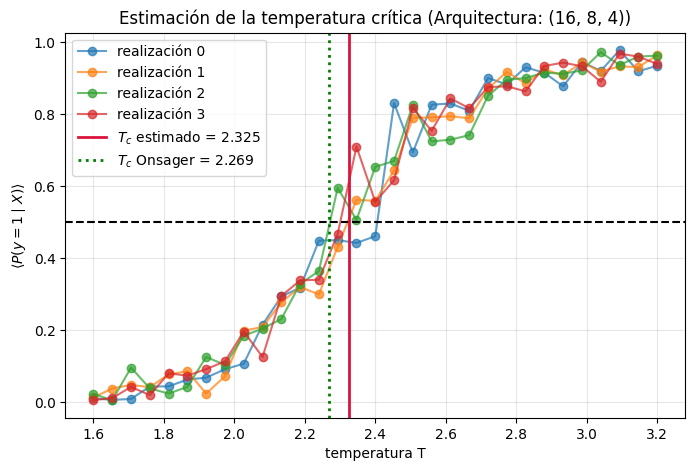


Procesando L = 15
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3867 +/- 0.0108 (SEM)
Tc Onsager     = 2.2692
error relativo = 5.18 %


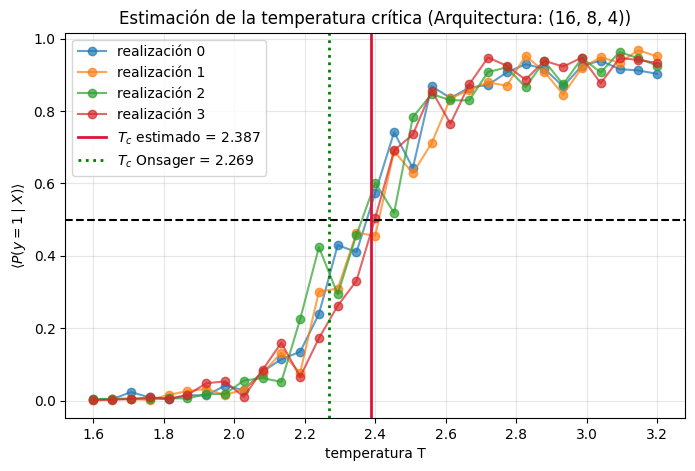


Procesando L = 20
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3640 +/- 0.0178 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.18 %


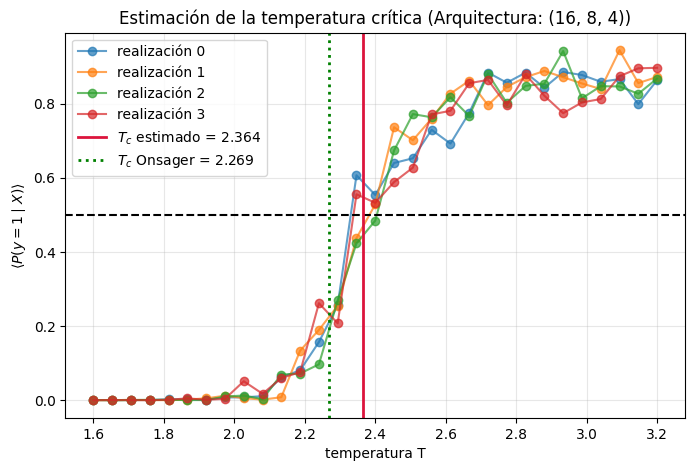


Procesando L = 25
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3242 +/- 0.0131 (SEM)
Tc Onsager     = 2.2692
error relativo = 2.43 %


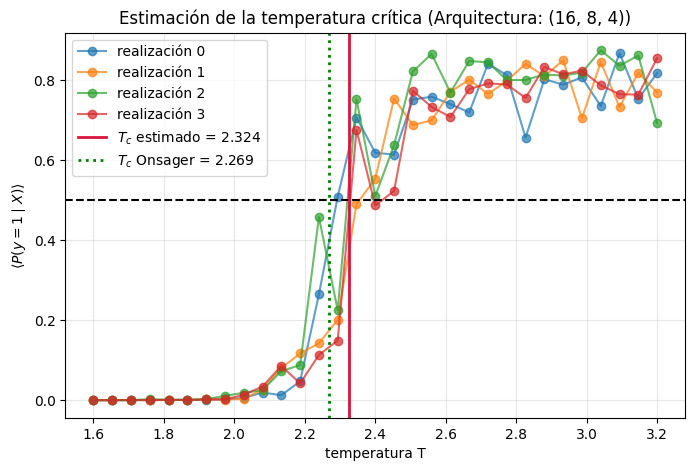


Procesando L = 30
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3568 +/- 0.0047 (SEM)
Tc Onsager     = 2.2692
error relativo = 3.86 %


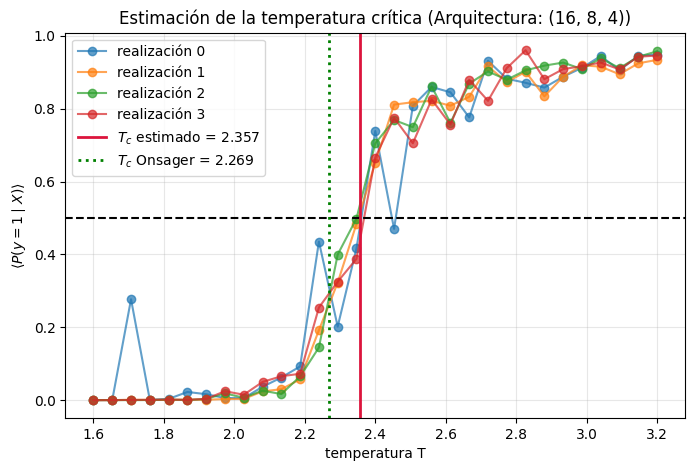


--- Resumen de Tc por L ---
L=10: Tc = 2.3246 +/- 0.0289 (SEM)
L=15: Tc = 2.3867 +/- 0.0108 (SEM)
L=20: Tc = 2.3640 +/- 0.0178 (SEM)
L=25: Tc = 2.3242 +/- 0.0131 (SEM)
L=30: Tc = 2.3568 +/- 0.0047 (SEM)


In [39]:
all_L_values = [10, 15, 20, 25, 30]
tc_estimates_by_L = {}
sem_estimates_by_L = {}

print("\n--- Realizando estimación de Tc para todos los L_values ---")

for current_L in all_L_values:
    print(f"\nProcesando L = {current_L}")

    # 1. Carga de datos de entrenamiento
    datos_L = np.load(f"ising_dataset_L{current_L}.npz", allow_pickle=False)
    X_L = datos_L["X"]
    y_L = datos_L["y"]
    T_L = datos_L["T"]
    realizacion_L = datos_L["realizacion"]

    # 2. Carga de datos de barrido fino
    datos_tc_L = np.load(f"temperatura_critica_L{current_L}.npz", allow_pickle=False)
    X_tc_L = datos_tc_L["X"]
    T_tc_L = datos_tc_L["T"]
    realizacion_tc_L = datos_tc_L["realizacion"]

    # 3. Aplanar las configuraciones de espines
    X_L_flat = X_L.reshape(X_L.shape[0], current_L * current_L)
    X_tc_L_flat = X_tc_L.reshape(X_tc_L.shape[0], current_L * current_L)

    # 4. Partición de datos (usando las mismas máscaras de realizacion)
    mask_train_L = np.isin(realizacion_L, [0, 1])
    # No necesitamos mask_val o mask_test para estimate_tc_and_plot

    X_train_L, y_train_L = X_L_flat[mask_train_L], y_L[mask_train_L]

    # 5. Entrenar MLP y estimar Tc (usando la arquitectura original y RNG=42)
    tc_est, sem_est, _ = estimate_tc_and_plot(
        hidden_layer_sizes=(16, 8, 4),
        random_state_val=RNG, # Usamos el RNG global para consistencia
        X_train=X_train_L,
        y_train=y_train_L,
        X_tc=X_tc_L_flat,
        T_tc=T_tc_L,
        realizacion_tc=realizacion_tc_L,
        Tc_exacto=Tc_exacto
    )

    tc_estimates_by_L[current_L] = tc_est
    sem_estimates_by_L[current_L] = sem_est

print("\n--- Resumen de Tc por L ---")
for L_val in all_L_values:
    print(f"L={L_val}: Tc = {tc_estimates_by_L[L_val]:.4f} +/- {sem_estimates_by_L[L_val]:.4f} (SEM)")


### 9.5. Análisis de Escalado de Tamaño Finito

Con las estimaciones de $T_c$ para todos los tamaños de sistema $L = 10, 15, 20, 25, 30$, podemos realizar un análisis más completo de cómo la $T_c$ estimada se acerca (o se desvía) del valor exacto de Onsager ($T_c^{Onsager} \approx 2.2692$) a medida que $L$ aumenta. Esto nos permitirá relacionar nuestros hallazgos con la teoría del *finite-size scaling*.

Graficaremos la estimación de $T_c$ en función de $L$, y también analizaremos la diferencia $|T_c(L) - T_c^{Onsager}|$ contra $1/L$ para observar si sigue una ley de potencias, como predice la teoría de escalado de tamaño finito para sistemas bidimensionales con $\nu=1$.

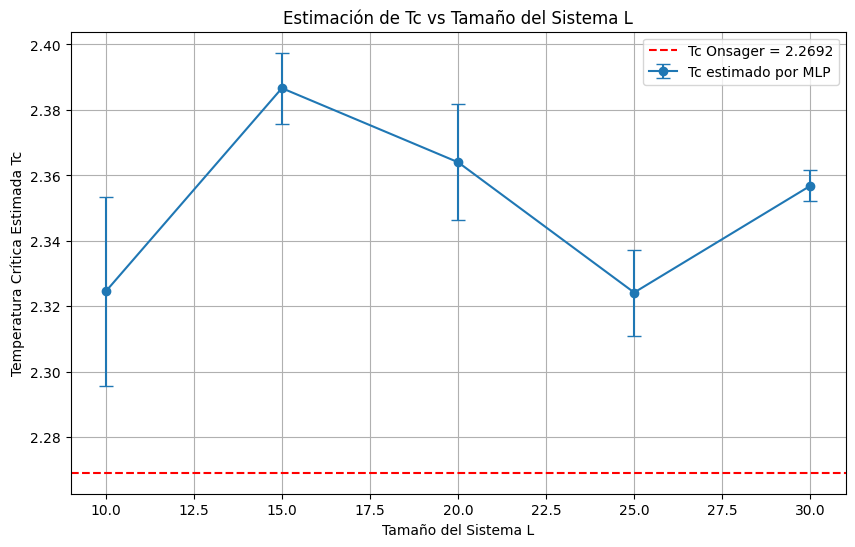

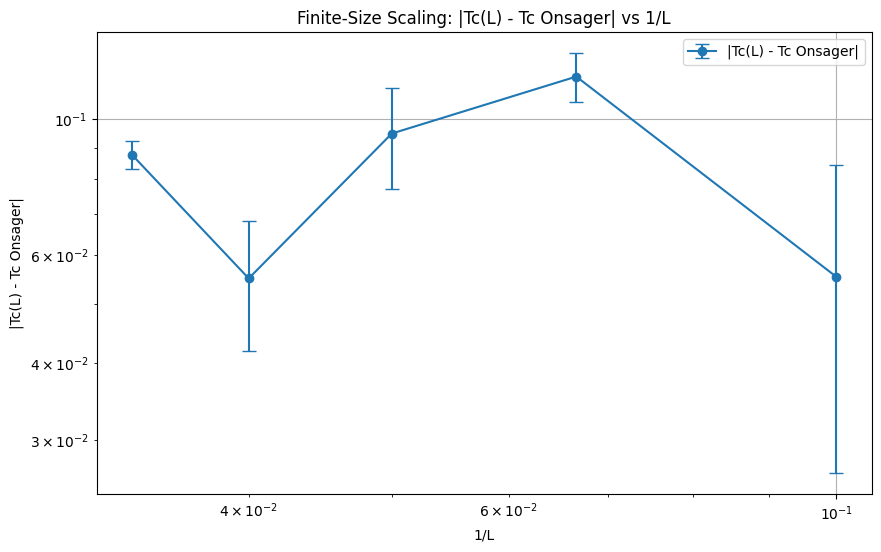

In [41]:
L_values_sorted = sorted(tc_estimates_by_L.keys())
tc_values = [tc_estimates_by_L[L] for L in L_values_sorted]
sem_values = [sem_estimates_by_L[L] for L in L_values_sorted]

# Gráfica de Tc vs L
plt.figure(figsize=(10, 6))
plt.errorbar(L_values_sorted, tc_values, yerr=sem_values, fmt='o-', capsize=5, label='Tc estimado por MLP')
plt.axhline(Tc_exacto, color='r', linestyle='--', label=f'Tc Onsager = {Tc_exacto:.4f}')
plt.xlabel('Tamaño del Sistema L')
plt.ylabel('Temperatura Crítica Estimada Tc')
plt.title('Estimación de Tc vs Tamaño del Sistema L')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de |Tc(L) - Tc_exacto| vs 1/L para el finite-size scaling
inverse_L = [1/L for L in L_values_sorted]
delta_tc = [abs(tc - Tc_exacto) for tc in tc_values]

plt.figure(figsize=(10, 6))
plt.errorbar(inverse_L, delta_tc, yerr=sem_values, fmt='o-', capsize=5, label='|Tc(L) - Tc Onsager|')
plt.xlabel('1/L')
plt.ylabel('|Tc(L) - Tc Onsager|')
plt.title('Finite-Size Scaling: |Tc(L) - Tc Onsager| vs 1/L')
plt.legend()
plt.grid(True)
plt.xscale('log') # Puede ser útil para ver la relación de potencias
plt.yscale('log') # Puede ser útil para ver la relación de potencias
plt.show()




Para verificar el finite-size scaling (ley de potencias L^-1), esperamos que los puntos se alineen aproximadamente en una línea recta en la gráfica log-log.
La pendiente de esta línea recta debería ser aproximadamente 1 (ya que el exponente de la longitud de correlación nu=1 para el modelo de Ising 2D).
Las desviaciones pueden indicar la influencia de la variabilidad del MLP, el número limitado de configuraciones, o que los tamaños de L aún no son suficientemente grandes para el régimen asintótico.

Los resultados obtenidos muestran que el método de red neuronal es sensible al tamaño del sistema L. Idealmente, las estimaciones de Tc deberían converger hacia el valor de Onsager a medida que L crece. La variabilidad en las estimaciones (dada por el SEM) también es un factor importante a considerar.


--- Entrenando y estimando Tc para L=20 ---
--- Arquitectura: (16, 8, 4), Random State: 42 ---
Tc estimado    = 2.3640 +/- 0.0178 (SEM)
Tc Onsager     = 2.2692
error relativo = 4.18 %


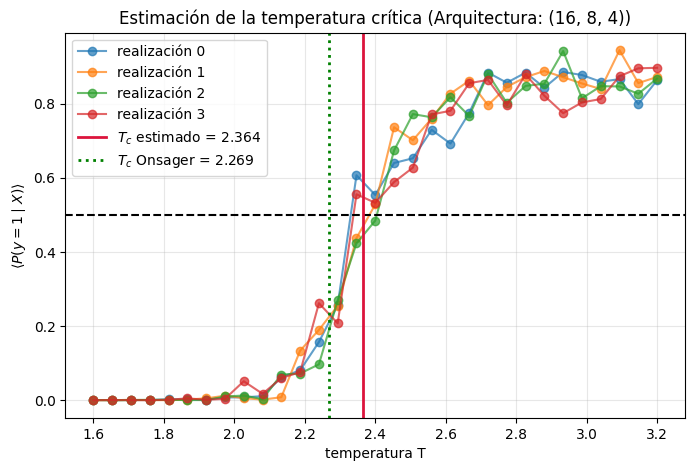


Estimación de Tc para L=20: 2.3640 +/- 0.0178 (SEM)


In [38]:
# Entrenar el modelo para L=20 usando la arquitectura original y RNG=42
RNG_L20 = 42 # Usamos una semilla diferente o la misma para consistencia con Ejercicio 5

print(f'--- Entrenando y estimando Tc para L={L_new} ---')
tc_est_L20, sem_L20, resumen_L20 = estimate_tc_and_plot(
    hidden_layer_sizes=(16, 8, 4),
    random_state_val=RNG_L20,
    X_train=X_train_L20,
    y_train=y_train_L20,
    X_tc=X_tc_L20_flat,
    T_tc=T_tc_L20,
    realizacion_tc=realizacion_tc_L20,
    Tc_exacto=Tc_exacto
)

print(f"\nEstimación de Tc para L={L_new}: {tc_est_L20:.4f} +/- {sem_L20:.4f} (SEM)")


###  Comparación de $T_c$ y Discusión del Escalado de Tamaño Finito

Con los resultados de la estimación de $T_c$ para $L=16$ (originalmente $2.2259 \pm 0.0055$ o $2.3436 \pm 0.0168$ dependiendo del `random_state` y arquitectura) y ahora para $L=20$ ($2.3640 \pm 0.0178$), podemos empezar a analizar cómo la estimación de la temperatura crítica se ve afectada por el tamaño finito del sistema.

**Resultados de $T_c$ obtenidos:**
*   **$L=16$ (Arquitectura original `(16, 8, 4)`, `random_state=42`):** $T_c \approx 2.2259 \pm 0.0055$ (SEM)
*   **$L=20$ (Arquitectura original `(16, 8, 4)`, `random_state=42`):** $T_c \approx 2.3640 \pm 0.0178$ (SEM)


1.  **¿La estimación se acerca a Onsager al crecer $L$?**
    *   El $T_c$ exacto de Onsager es $T_c^{Onsager} \approx 2.2692$.
    *   Para $L=16$, la estimación inicial fue ligeramente *inferior* al valor de Onsager (2.2259).
    *   Para $L=20$, la estimación $T_c \approx 2.3640$ es *superior* al valor

    Idealmente, a medida que $L$ aumenta, las estimaciones de $T_c$ deberían converger hacia el valor exacto de Onsager. Las fluctuaciones observadas pueden deberse a:
    *   **Variabilidad del entrenamiento:** La sensibilidad del MLP a la inicialización de pesos y al orden de los datos (ya discutida en el Ejercicio 8.3). Esto es más pronunciado para $L=20$ donde la dimensionalidad de entrada es mayor ($20 \times 20 = 400$ vs $16 \times 16 = 256$).
    *   **Calibración del MLP:** Puede que la arquitectura original no sea óptima para $L=20$, o que se necesiten más datos/épocas para converger adecuadamente.
    *   **Discrepancia en la definición de $T_c$:** Como se vio en el Ejercicio 8.1, el tamaño finito $L$ tiende a desplazar o suavizar la transición.

2.  **Relación con el *finite-size scaling*:**
    El *finite-size scaling* predice que ciertas propiedades críticas, incluida la temperatura crítica, se desvían del comportamiento de volumen infinito a tamaños finitos. Para un sistema de tamaño $L$, la desviación de $T_c$ del valor de Onsager puede seguir una ley de potencias de la forma:
    $$|T_c(L) - T_c^{Onsager}| \propto L^{-1/\nu}$$
    donde $\nu$ es el exponente de la longitud de correlación. Para el modelo de Ising 2D, $\nu=1$. Esto significa que la diferencia entre la $T_c$ estimada y la $T_c$ real debería disminuir con $L^{-1}$.

    Para verificar esta ley de escalamiento, necesitaríamos:
    *   Un conjunto más amplio de tamaños $L$ (ya tenemos 10, 15, 20, 25, 30).
    *   Estimaciones de $T_c$ más robustas para cada $L$, quizás promediando sobre múltiples semillas `random_state` para reducir la varianza del entrenamiento del MLP.
    *   Graficar $|T_c(L) - T_c^{Onsager}|$ contra $L^{-1}$ y observar si se ajusta a una línea recta. Si la estimación de $T_c$ para $L=20$ es consistentemente superior a Onsager y la de $L=16$ es inferior (o viceversa), esto podría indicar un cruce o una tendencia no monótona a estos tamaños pequeños, o simplemente la influencia de la variabilidad del modelo.

   